In [1]:
import numpy as np
import pandas as pd
import csv
import random
from sklearn.linear_model import LogisticRegression
import sys
import os

sys.path.insert(0, "../../../Modules")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)
random.seed(0)
np.random.seed(0)

from utils import *

enc = 'utf-8'

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'

In [4]:
YEAR = 2023

In [5]:
#class ratio must be [0,1]
#lower number means more aggressive spliting towards the higher classes

NUMBER_OF_CLASSES = 10
CLASS_RATIO = 0.55

In [6]:
base_path = f'../../data/{NUTS2}/results/'

In [7]:
file_list = os.listdir(base_path)
file_list.sort()
file_list

['GR_CMacedonia_Results_2010-2022.csv',
 'GR_CMacedonia_Results_2023-August-1st.csv',
 'GR_CMacedonia_Results_2023-July-1st.csv',
 'GR_CMacedonia_Results_2023-July-2nd.csv',
 'GR_CMacedonia_Results_2023-June-1st.csv',
 'GR_CMacedonia_Results_2023-June-2nd.csv',
 'GR_CMacedonia_Results_2023-May-1st.csv',
 'GR_CMacedonia_Results_2023-May-2nd.csv']

In [8]:
file = file_list[0]

data = pd.read_csv(f'{base_path}/{file}', encoding='utf-8')
data.drop(columns=['x', 'y'], inplace=True)
data.rename(columns={"probability": "score", "municipality": "lau1"}, inplace=True)


In [9]:
data

,lau1,day,month,year,case,score
0,θεσσαλονικης,16,8,2021,0,9.894434e-01
1,αλεξανδρειας,16,8,2021,1,9.887726e-01
2,αλεξανδρειας,1,8,2021,1,9.885786e-01
3,δελτα,1,9,2012,0,9.863749e-01
4,αλεξανδρειας,1,9,2021,1,9.861289e-01
...,...,...,...,...,...,...
5923,διου ολυμπου,16,11,2010,0,7.424888e-06
5924,νεαπολης συκεων,16,11,2010,0,6.447226e-06
5925,κασσανδρας,16,11,2010,0,3.871581e-06
5926,σιθωνιας,1,11,2010,0,2.347759e-06


In [10]:
data_og = data.copy()

In [11]:
np.sort(data.month.unique())

array([ 6,  7,  8,  9, 10, 11], dtype=int64)

In [12]:
np.sort(data.year.unique())

array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022], dtype=int64)

In [13]:
zero_score = {'lau1': 'αγνωστη', 'day': 0, 'month': 0, 'year': 0, 'case': 0, 'score': 0}
one_score = {'lau1': 'αγνωστη', 'day': 0, 'month': 0, 'year': 0, 'case': 0, 'score': 1}

In [14]:
data = data.append(zero_score, ignore_index = True)
data = data.append(one_score, ignore_index = True)

In [15]:
data

,lau1,day,month,year,case,score
0,θεσσαλονικης,16,8,2021,0,9.894434e-01
1,αλεξανδρειας,16,8,2021,1,9.887726e-01
2,αλεξανδρειας,1,8,2021,1,9.885786e-01
3,δελτα,1,9,2012,0,9.863749e-01
4,αλεξανδρειας,1,9,2021,1,9.861289e-01
...,...,...,...,...,...,...
5925,κασσανδρας,16,11,2010,0,3.871581e-06
5926,σιθωνιας,1,11,2010,0,2.347759e-06
5927,σιθωνιας,16,11,2010,0,6.556912e-07
5928,αγνωστη,0,0,0,0,0.000000e+00


In [16]:
data_sorted = data.sort_values(by='score', ascending=True)

In [17]:
data_sorted.reset_index(drop = True, inplace = True)

In [18]:
data_sorted

,lau1,day,month,year,case,score
0,αγνωστη,0,0,0,0,0.000000e+00
1,σιθωνιας,16,11,2010,0,6.556912e-07
2,σιθωνιας,1,11,2010,0,2.347759e-06
3,κασσανδρας,16,11,2010,0,3.871581e-06
4,νεαπολης συκεων,16,11,2010,0,6.447226e-06
...,...,...,...,...,...,...
5925,δελτα,1,9,2012,0,9.863749e-01
5926,αλεξανδρειας,1,8,2021,1,9.885786e-01
5927,αλεξανδρειας,16,8,2021,1,9.887726e-01
5928,θεσσαλονικης,16,8,2021,0,9.894434e-01


<AxesSubplot:>

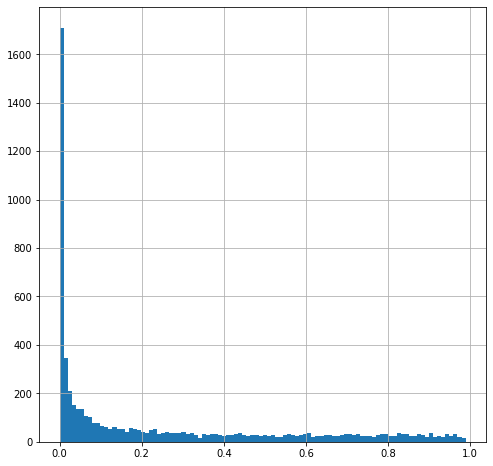

In [19]:
data_og.score.hist(bins = 100, figsize = (8,8))

In [20]:
number_of_observations = len(data_sorted)

In [21]:
r_sum = 0

for i in range(NUMBER_OF_CLASSES):
    r_sum = r_sum + CLASS_RATIO**i

x = round(number_of_observations/r_sum)

x

2675

In [22]:
temp_x = x
total_obs = 0
obs = []

for c in range(NUMBER_OF_CLASSES):
    total_obs = total_obs + temp_x
    obs.append(temp_x)
    print(f'Class {c}: {temp_x} observations')
    temp_x = round(temp_x*CLASS_RATIO)
    
print(f'\nTotal Observations: {total_obs}')

Class 0: 2675 observations
Class 1: 1471 observations
Class 2: 809 observations
Class 3: 445 observations
Class 4: 245 observations
Class 5: 135 observations
Class 6: 74 observations
Class 7: 41 observations
Class 8: 23 observations
Class 9: 13 observations

Total Observations: 5931


In [23]:
bins = []
sum = 0
for index in obs:
    sum = sum + index
    try:
        bin_lim = data_sorted.loc[sum, 'score']
    except KeyError:
        bin_lim = data_sorted.loc[number_of_observations-1, 'score']
    bins.append(bin_lim)

bins.insert(0,0)
bins[-1] = 1 

In [24]:
data_og['risk_class'] = pd.cut(data_og['score'], bins=bins, labels=False, include_lowest=True)

data_og.risk_class.value_counts().sort_index()

0    2675
1    1471
2     809
3     445
4     245
5     135
6      74
7      41
8      23
9      10
Name: risk_class, dtype: int64

In [25]:
bins_formatted = [ '%.4f' % elem for elem in bins]
print(bins_formatted)

['0.0000', '0.0584', '0.3421', '0.6302', '0.7928', '0.8781', '0.9285', '0.9569', '0.9693', '0.9819', '1.0000']


In [26]:
bins_path = f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Bins_{YEAR}.csv'

with open(bins_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(bins)

In [27]:
class9 = data_og.loc[data_og.risk_class == 9]
class8 = data_og.loc[data_og.risk_class == 8]
class7 = data_og.loc[data_og.risk_class == 7]
class6 = data_og.loc[data_og.risk_class == 6]
class5 = data_og.loc[data_og.risk_class == 5]
class4 = data_og.loc[data_og.risk_class == 4]
class3 = data_og.loc[data_og.risk_class == 3]
class2 = data_og.loc[data_og.risk_class == 2]
class1 = data_og.loc[data_og.risk_class == 1]
class0 = data_og.loc[data_og.risk_class == 0]

In [28]:
means = []
means.append(class9.case.mean())
means.append(class8.case.mean())
means.append(class7.case.mean())
means.append(class6.case.mean())
means.append(class5.case.mean())
means.append(class4.case.mean())
means.append(class3.case.mean())
means.append(class2.case.mean())
means.append(class1.case.mean())
means.append(class0.case.mean())


In [29]:
means

[0.3,
 0.30434782608695654,
 0.3170731707317073,
 0.22972972972972974,
 0.24444444444444444,
 0.17551020408163265,
 0.1303370786516854,
 0.12237330037082818,
 0.09653297076818491,
 0.010093457943925233]

In [30]:
class0.sort_values(by='score', ascending=False, inplace = True, ignore_index = True)

In [31]:
class0

,lau1,day,month,year,case,score,risk_class
0,νεαπολης συκεων,16,6,2018,0,5.838971e-02,0
1,αριστοτελη,1,9,2011,0,5.833896e-02,0
2,αλεξανδρειας,16,6,2014,0,5.818340e-02,0
3,αλεξανδρειας,1,6,2015,0,5.812460e-02,0
4,εδεσσας,1,10,2022,0,5.803598e-02,0
...,...,...,...,...,...,...,...
2670,διου ολυμπου,16,11,2010,0,7.424888e-06,0
2671,νεαπολης συκεων,16,11,2010,0,6.447226e-06,0
2672,κασσανδρας,16,11,2010,0,3.871581e-06,0
2673,σιθωνιας,1,11,2010,0,2.347759e-06,0


In [32]:
class0_1 = class0.iloc[:1350]
class0_2 = class0.iloc[1351:]

In [33]:
class0_1

,lau1,day,month,year,case,score,risk_class
0,νεαπολης συκεων,16,6,2018,0,0.058390,0
1,αριστοτελη,1,9,2011,0,0.058339,0
2,αλεξανδρειας,16,6,2014,0,0.058183,0
3,αλεξανδρειας,1,6,2015,0,0.058125,0
4,εδεσσας,1,10,2022,0,0.058036,0
...,...,...,...,...,...,...,...
1345,θεσσαλονικης,1,11,2015,0,0.004119,0
1346,σερρων,1,11,2014,0,0.004114,0
1347,εδεσσας,1,11,2015,0,0.004105,0
1348,κασσανδρας,16,6,2016,0,0.004094,0


In [34]:
class0_2

,lau1,day,month,year,case,score,risk_class
1351,νεας ζιχνης,16,6,2019,0,4.070945e-03,0
1352,πυλαιας χορτιατη,16,6,2020,0,4.056807e-03,0
1353,αμπελοκηπων μενεμενης,1,6,2016,0,4.031252e-03,0
1354,νεαπολης συκεων,16,11,2018,0,4.007501e-03,0
1355,αλεξανδρειας,1,11,2014,0,4.006464e-03,0
...,...,...,...,...,...,...,...
2670,διου ολυμπου,16,11,2010,0,7.424888e-06,0
2671,νεαπολης συκεων,16,11,2010,0,6.447226e-06,0
2672,κασσανδρας,16,11,2010,0,3.871581e-06,0
2673,σιθωνιας,1,11,2010,0,2.347759e-06,0


In [35]:
class0_1.case.mean()

0.018518518518518517

In [36]:
class0_2.case.mean()

0.0015105740181268882

In [37]:
means.append(class0_1.case.mean())
means.append(class0_2.case.mean())

In [38]:
del means[9]

In [39]:
means

[0.3,
 0.30434782608695654,
 0.3170731707317073,
 0.22972972972972974,
 0.24444444444444444,
 0.17551020408163265,
 0.1303370786516854,
 0.12237330037082818,
 0.09653297076818491,
 0.018518518518518517,
 0.0015105740181268882]

In [49]:
class_very_high = pd.concat([class9, class8, class7])
class_very_high.reset_index(drop = True, inplace = True)
class_very_high

print(f'Threashold: ({class_very_high.score.min():.3f} - {class_very_high.score.max():.3f})')
print(f'Samples: {len(class_very_high)}')
print(f'% Samples: {len(class_very_high)/len(data_og) * 100:.3f} %')
print(f'Accuracy: {class_very_high.case.mean() * 100 :.2f} %')

Threashold: (0.957 - 0.989)
Samples: 74
% Samples: 1.248 %
Accuracy: 31.08 %


In [48]:
class_high = pd.concat([class6, class5])
class_high.reset_index(drop = True, inplace = True)
class_high

print(f'Threashold: ({class_high.score.min():.3f} - {class_high.score.max():.3f})')
print(f'Samples: {len(class_high)}')
print(f'% Samples: {len(class_high)/len(data_og) * 100:.3f} %')
print(f'Accuracy: {class_high.case.mean() * 100 :.2f} %')

Threashold: (0.879 - 0.957)
Samples: 209
% Samples: 3.526 %
Accuracy: 23.92 %


In [47]:
class_mid_high = pd.concat([class4, class3])
class_mid_high.reset_index(drop = True, inplace = True)
class_mid_high

print(f'Threashold: ({class_mid_high.score.min():.3f} - {class_mid_high.score.max():.3f})')
print(f'Samples: {len(class_mid_high)}')
print(f'% Samples: {len(class_mid_high)/len(data_og) * 100:.3f} %')
print(f'Accuracy: {class_mid_high.case.mean() * 100 :.2f} %')

Threashold: (0.632 - 0.878)
Samples: 690
% Samples: 11.640 %
Accuracy: 14.64 %


In [46]:
class_mid = pd.concat([class2, class1])
class_mid.reset_index(drop = True, inplace = True)
class_mid

print(f'Threashold: ({class_mid.score.min():.3f} - {class_mid.score.max():.3f})')
print(f'Samples: {len(class_mid)}')
print(f'% Samples: {len(class_mid)/len(data_og) * 100:.3f} %')
print(f'Accuracy: {class_mid.case.mean() * 100 :.2f} %')

Threashold: (0.058 - 0.630)
Samples: 2280
% Samples: 38.462 %
Accuracy: 10.57 %


In [50]:
class_low = class0_1
class_low.reset_index(drop = True, inplace = True)
class_low

print(f'Threashold: ({class_low.score.min():.3f} - {class_low.score.max():.3f})')
print(f'Samples: {len(class_low)}')
print(f'% Samples: {len(class_low)/len(data_og) * 100:.3f} %')
print(f'Accuracy: {class_low.case.mean() * 100 :.2f} %')

Threashold: (0.004 - 0.058)
Samples: 1350
% Samples: 22.773 %
Accuracy: 1.85 %


In [51]:
class_very_low = class0_2
class_very_low.reset_index(drop = True, inplace = True)
class_very_low

print(f'Threashold: ({class_very_low.score.min():.3f} - {class_very_low.score.max():.3f})')
print(f'Samples: {len(class_very_low)}')
print(f'% Samples: {len(class_very_low)/len(data_og) * 100:.3f} %')
print(f'Accuracy: {class_very_low.case.mean() * 100 :.2f} %')

Threashold: (0.000 - 0.004)
Samples: 1324
% Samples: 22.335 %
Accuracy: 0.15 %
